# Caracterización Automatizada del Comparador Dinámico
---
**Autor:** Antigravity AI Partner  
**PDK:** GF180MCU 3.3V  
**Herramientas:** ngspice + Python (Jupyter)

Este cuaderno de Jupyter permite realizar la simulación y caracterización automática de las tres métricas clave del comparador:
1. **Retardo Transitorio ($t_{pd}$)**
2. **Offset Dinámico ($V_{OS}$)**
3. **Consumo de Potencia Promedio ($P_{avg}$)**

Las simulaciones se ejecutan generando los netlists de testbench dinámicamente desde Python e incluyendo el circuito de transistores extraído de `comparador.sch`.


In [1]:
import os
import subprocess
import re
import numpy as np
import matplotlib.pyplot as plt

# Habilitar el backend interactivo para Jupyter (necesario para el puntero de medición)
%matplotlib widget
#X1 CLK_NEG VDD GND ViN VIP Op On  strongARM'
# =====================================================================
# CONFIGURACIÓN DE RELOJ GLOBAL Y CICLOS A MOSTRAR
# =====================================================================
CLK_FREQ = 100e6          # Frecuencia de reloj (Hz) - por defecto 100 MHz 
CLK_PERIOD = 1 / CLK_FREQ  # Periodo de reloj (s) derivado automáticamente = 10n' 'X1 CLK_NEG VDD GND ViN VIP Op On  strongARM'
NUM_CYCLES = 4            # Número de ciclos de reloj a simular y mostrar (Debe ser > 1 para potencia)

# Rutas del PDK y del proyecto
PDK_PATH = '/foss/pdks/gf180mcuD'
SIM_DIR = '/headless/.xschem/simulations'
os.makedirs(SIM_DIR, exist_ok=True)
SCH_DIR = '/foss/designs/disenos_luigy'
CELL_NAME = 'strongARM'
CELL_INST_SPICE = 'X1 CLK_NEG VDD GND ViN VIP Op On  strongARM'

# Función interactiva para medir puntos al hacer clic
def habilitar_cursor_interactivo(fig, ax, x_unit="ns", y_unit="V"):
    annotations = []
    def onclick(event):
        if event.inaxes == ax:
            # Eliminar la anotación anterior si existe
            for annot in annotations:
                annot.remove()
            annotations.clear()
            
            x, y = event.xdata, event.ydata
            # Crear nueva anotación con las coordenadas exactas del clic
            annot = ax.annotate(
                f"({x:.3f}{x_unit}, {y:.3f}{y_unit})", 
                xy=(x, y), xytext=(20, 20), textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.8),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2")
            )
            annotations.append(annot)
            fig.canvas.draw_idle()
            
    fig.canvas.mpl_connect('button_press_event', onclick)

print(f"Entorno inicializado. Frecuencia de reloj: {CLK_FREQ/1e6:.1f} MHz (Periodo: {CLK_PERIOD*1e9:.2f} ns)")
print(f"Ciclos de reloj configurados para visualización: {NUM_CYCLES} ciclos")


Entorno inicializado. Frecuencia de reloj: 100.0 MHz (Periodo: 10.00 ns)
Ciclos de reloj configurados para visualización: 4 ciclos


In [2]:
class NgspiceRawReader:
    def __init__(self, filepath):
        self.filepath = filepath
        self.variables = []
        self.data = {}
        self.load()

    def load(self):
        if not os.path.exists(self.filepath):
            raise FileNotFoundError(f"No se encontró el archivo: {self.filepath}")
            
        with open(self.filepath, 'r') as f:
            lines = f.readlines()

        # Buscar variables
        data_start = 0
        for idx, line in enumerate(lines):
            if line.startswith('Variables:'):
                j = idx + 1
                while not lines[j].startswith('Values:'):
                    parts = lines[j].strip().split()
                    if len(parts) >= 3:
                        self.variables.append(parts[1])
                    j += 1
            if line.startswith('Values:'):
                data_start = j + 1
                break

        # Inicializar contenedores de datos
        for var in self.variables:
            self.data[var] = []

        # Leer valores
        i = data_start
        while i < len(lines):
            line = lines[i].strip()
            if not line:
                i += 1
                continue
            parts = line.split()
            if len(parts) == 2:
                self.data[self.variables[0]].append(float(parts[1]))
                for v_idx in range(1, len(self.variables)):
                    val_line = lines[i + v_idx].strip()
                    self.data[self.variables[v_idx]].append(float(val_line))
                i += len(self.variables)
            else:
                i += 1
                
        # Convertir a arrays de numpy
        for var in self.variables:
            self.data[var] = np.array(self.data[var])
            
    def get_signal(self, name):
        name_lower = name.lower()
        for var in self.variables:
            if var.lower() == name_lower:
                return self.data[var]
        raise KeyError(f"Señal no encontrada: {name}. Disponibles: {self.variables}")

## 2. Compilación del Comparador Bajo Prueba (DUT)
Genera el netlist de transistores de `comparador.sch` y limpia la definición de subcircuito para ser incluida en los testbenches.


In [3]:
print("1. Re-generando netlist de strongARM.sch...")
env = os.environ.copy()
env["PDK_ROOT"] = "/foss/pdks"
env["PDK"] = "gf180mcuD"
env["PDKPATH"] = "/foss/pdks/gf180mcuD"
env["PWD"] = SCH_DIR
subprocess.run(
    f"source /headless/.bashrc && xschem -n -q -o {SCH_DIR} {SCH_DIR}/{CELL_NAME}.sch",
    shell=True, executable='/bin/bash', check=True,
    cwd=SCH_DIR
)


# Limpiar el netlist del comparador para remover comentarios de subcircuito
input_file = os.path.join(SCH_DIR, f'{CELL_NAME}.spice')
output_file = os.path.join(SCH_DIR, f'{CELL_NAME}_clean.spice')

with open(input_file, 'r') as f:
    content = f.read()

cleaned = content.replace('**.subckt', '.subckt')
cleaned = cleaned.replace('**.ends', '.ends')

with open(output_file, 'w') as f:
    f.write(cleaned)
print(output_file)
print("Netlist limpio de transistores generado en strongARM_clean.spice")


1. Re-generando netlist de strongARM.sch...
[INFO] Final PATH variable: /foss/tools/bin:/foss/tools/sak:/usr/local/sbin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/foss/tools/kactus2:/foss/tools/klayout:/foss/tools/osic-multitool
[INFO] Final PYTHONPATH variable: /usr/lib/python312.zip:/usr/lib/python3.12:/usr/lib/python3.12/lib-dynload:/usr/local/lib/python3.12/dist-packages:/usr/lib/python3/dist-packages:/foss/tools/ngspyce/local/lib/python3.12/dist-packages:/foss/tools/openems/local/lib/python3.12/dist-packages:/foss/tools/yosys/share/yosys/python3:/foss/tools/klayout/pymod
PDK_ROOT=/foss/pdks
PDK=gf180mcuD
PDKPATH=/foss/pdks/gf180mcuD
STD_CELL_LIBRARY=gf180mcu_fd_sc_mcu7t5v0
setup_tcp_bespice: problems finding a free TCP port
couldn't open socket: address already in use

/foss/designs/disenos_luigy/strongARM_clean.spice
Netlist limpio de transistores generado en strongARM_clean.spice


Using run time directory XSCHEM_SHAREDIR = /foss/tools/xschem/share/xschem
Sourcing /foss/tools/xschem/share/xschem/xschemrc init file
Sourcing /headless/.xschem/xschemrc init file
pdk installation: using /foss/pdks
180MCU_MODELS: /foss/pdks/gf180mcuD/libs.tech/ngspice


## 3. Caracterización de Retardo Transitorio ($t_{pd}$)

El **retardo de propagación ($t_{pd}$)** es el tiempo transcurrido desde el flanco de bajada de $CLK\_NEG$ (inicio de evaluación) hasta la transición de la salida activa. Con entradas $V_{IP} > V_{IN}$, la rama de entrada PFET de $V_{IN}$ (`XM4`) conduce más corriente que `XM3`, cargando el nodo `AN` más rápido y encendiendo el NFET `XM10` para descargar la salida `ON` a GND (mientras `OP` queda en VDD). Así, el retardo se mide en la bajada de `ON` al 50% de $V_{DD}$ ($1.65\,\text{V}$):

$$t_{pd} = t\left(v(O_N) = 1.65\,\text{V}\right) - t\left(v(CLK\_NEG) = 1.65\,\text{V}\right)$$

En SPICE se extrae directamente con la siguiente directiva:
```spice
.measure tran tpd_ON TRIG v(CLK_NEG) VAL=1.65 FALL=1 TD=500p TARG v(On) VAL=1.65 FALL=1
```


In [4]:
spice_file = os.path.join(SIM_DIR, 'tb_comparador_transitorio.spice')
raw_file = os.path.join(SIM_DIR, 'tb_comparador_transitorio_output.raw')

print("1. Generando netlist transitorio...")
spice_code = f"""* Testbench Delay
.include {PDK_PATH}/libs.tech/ngspice/design.ngspice
.lib {PDK_PATH}/libs.tech/ngspice/sm141064.ngspice typical
.lib {PDK_PATH}/libs.tech/ngspice/sm141064.ngspice res_typical
.lib {PDK_PATH}/libs.tech/ngspice/sm141064.ngspice mimcap_typical
.lib {PDK_PATH}/libs.tech/ngspice/sm141064.ngspice cap_mim

.include {SCH_DIR}/{CELL_NAME}_clean.spice


{CELL_INST_SPICE}

V1 VDD GND 3.3
V2 VIP GND 1.70
V4 ViN GND 1.60
V3 CLK_NEG GND pulse(3.3 0 1n 100p 100p {CLK_PERIOD/2} {CLK_PERIOD})

.tran 5p {NUM_CYCLES * CLK_PERIOD}
.measure tran tpd_ON
+ TRIG v(CLK_NEG) VAL=1.65 FALL=1 TD=500p
+ TARG v(On)      VAL=1.65 FALL=1

.control
  set filetype=ascii
  run
  write {raw_file}
  quit
.endc
.end
"""

with open(spice_file, 'w') as f:
    f.write(spice_code)

print("2. Ejecutando simulación en ngspice...")
res = subprocess.run(
    'source /headless/.bashrc && ngspice -b ' + spice_file,
    shell=True, executable='/bin/bash', capture_output=True, text=True, check=True
)

# Buscar la medición tpd_on en la salida
tpd_match = re.search(r'tpd_on\s*=\s*([0-9e.+-]+)', res.stdout, re.IGNORECASE)
if tpd_match:
    tpd_val = float(tpd_match.group(1)) * 1e12
    print(f"\n>>> Retardo de propagación medido: {tpd_val:.2f} ps")
else:
    print("\nAdvertencia: No se pudo extraer la medida tpd_on del log de ngspice.")

# Cargar datos y graficar
reader = NgspiceRawReader(raw_file)
time = reader.get_signal('time') * 1e9
vclk = reader.get_signal('v(clk_neg)')
vop = reader.get_signal('v(op)')
von = reader.get_signal('v(on)')

import plotly.graph_objects as px
fig = px.Figure()
fig.add_trace(px.Scatter(x=time, y=vclk, name='CLK_NEG', line=dict(color='gray', dash='dash')))
fig.add_trace(px.Scatter(x=time, y=vop, name='Op (Salida V+)', line=dict(color='red', width=2)))
fig.add_trace(px.Scatter(x=time, y=von, name='On (Salida V-)', line=dict(color='blue', width=2)))
fig.update_xaxes(range=[0, NUM_CYCLES * CLK_PERIOD * 1e9])
fig.update_layout(
    title='Simulación Transitoria: Retardo del Comparador',
    xaxis_title='Tiempo (ns)',
    yaxis_title='Tensión (V)',
    hovermode="x unified",
    height=500,
    width=1000
)
fig.show()


1. Generando netlist transitorio...
2. Ejecutando simulación en ngspice...

>>> Retardo de propagación medido: 1079.62 ps


## 4. Caracterización de Offset Dinámico ($V_{OS}$)

El **offset dinámico ($V_{OS}$)** es la desviación del umbral de decisión real respecto al ideal ($V_{ID} = 0\,\text{V}$) debida a acoplamientos capacitivos (*kickback noise*) y asimetrías de conmutación. Se mide fijando la referencia $V_{IN} = 1.65\,\text{V}$ y aplicando una rampa lineal lenta en $V_{VIP}$ ($1.57\,\text{V}$ a $1.73\,\text{V}$) a lo largo de varios ciclos de reloj. En el instante exacto en que el comparador invierte su decisión y la salida `On` cae a $0\,\text{V}$, capturamos la tensión de entrada $V_{VIP}$ y calculamos:

$$V_{OS} = V_{IP,cruce} - 1.65\,\text{V}$$

En SPICE se extrae en una sola simulación mediante la directiva:
```spice
.measure tran VVIP_cross FIND v(VIP) WHEN v(On)=1.65 FALL=1
```


1. Generando netlist de offset...
2. Ejecutando simulación en ngspice...

>>> Cruce detectado a VIP = 1.6506 V
>>> Offset Dinámico del comparador: 0.59 mV


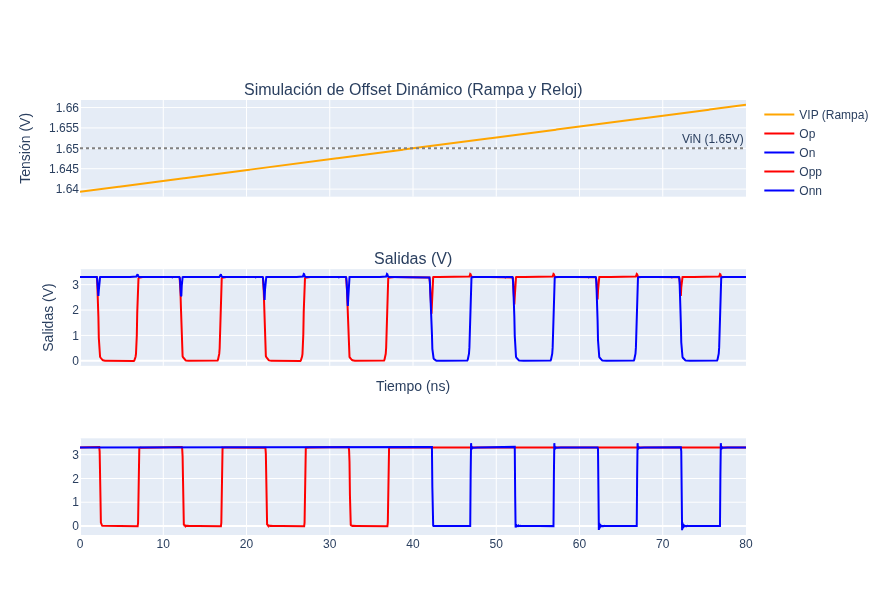

In [9]:
spice_file = os.path.join(SIM_DIR, 'tb_comparador_offset.spice')
raw_file = os.path.join(SIM_DIR, 'tb_comparador_offset_output.raw')

sim_time = 8 * CLK_PERIOD  # Rampa optimizada de 8 ciclos de reloj para reducir el tiempo de simulación sin alterar la medida

print("1. Generando netlist de offset...")
spice_code = f"""* Testbench Offset
.include {PDK_PATH}/libs.tech/ngspice/design.ngspice
.lib {PDK_PATH}/libs.tech/ngspice/sm141064.ngspice typical
.lib {PDK_PATH}/libs.tech/ngspice/sm141064.ngspice res_typical
.lib {PDK_PATH}/libs.tech/ngspice/sm141064.ngspice mimcap_typical
.lib {PDK_PATH}/libs.tech/ngspice/sm141064.ngspice cap_mim

.include {SCH_DIR}/{CELL_NAME}_clean.spice


{CELL_INST_SPICE}

V1 VDD GND 3.3
V2 VIP GND pwl(0 1.63933333 {sim_time} 1.66066667)
V4 ViN GND 1.65
V3 CLK_NEG GND pulse(3.3 0 1n 100p 100p {CLK_PERIOD/2} {CLK_PERIOD})

.tran 50p {sim_time}
.measure tran VVIP_cross FIND v(VIP) WHEN v(On)=1.65 FALL=1

.control
  set filetype=ascii
  run
  write {raw_file}
  quit
.endc
.end
"""

with open(spice_file, 'w') as f:
    f.write(spice_code)

print("2. Ejecutando simulación en ngspice...")
res = subprocess.run(
    ['/foss/tools/ngspice/bin/ngspice', '-b', spice_file],
    capture_output=True, text=True, check=True
)

# Buscar la medición vvip_cross en la salida
cross_match = re.search(r'vvip_cross\s*=\s*([0-9e.+-]+)', res.stdout, re.IGNORECASE)
if cross_match:
    vvip_val = float(cross_match.group(1))
    vos_val = (vvip_val - 1.65) * 1e3
    print(f"\n>>> Cruce detectado a VIP = {vvip_val:.4f} V")
    print(f">>> Offset Dinámico del comparador: {vos_val:.2f} mV")
else:
    print("\nAdvertencia: No se pudo extraer la medida vvip_cross.")

# Cargar datos y graficar
reader = NgspiceRawReader(raw_file)
time = reader.get_signal('time') * 1e9
vclk = reader.get_signal('v(clk_neg)')
vop = reader.get_signal('v(op)')
von = reader.get_signal('v(on)')
vvip = reader.get_signal('v(vip)')

vopp = reader.get_signal('v(x1.opp)')
vonn = reader.get_signal('v(x1.onn)')




import plotly.graph_objects as px
from plotly.subplots import make_subplots

# Crear subplots (2 filas, 1 columna)
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, 
                    subplot_titles=('Simulación de Offset Dinámico (Rampa y Reloj)', 'Salidas (V)'))

# Gráfica 1
fig.add_trace(px.Scatter(x=time, y=vvip, name='VIP (Rampa)', line=dict(color='orange', width=2)), row=1, col=1)
fig.add_hline(y=1.65, line_dash="dot", line_color="gray", annotation_text="ViN (1.65V)", row=1, col=1)

# Gráfica 2
fig.add_trace(px.Scatter(x=time, y=vop, name='Op', line=dict(color='red')), row=2, col=1)
fig.add_trace(px.Scatter(x=time, y=von, name='On', line=dict(color='blue')), row=2, col=1)

fig.add_trace(px.Scatter(x=time, y=vopp, name='Opp', line=dict(color='red')), row=3, col=1)
fig.add_trace(px.Scatter(x=time, y=vonn, name='Onn', line=dict(color='blue')), row=3, col=1)

# Diseños y etiquetas
fig.update_xaxes(title_text="Tiempo (ns)", row=2, col=1)
fig.update_yaxes(title_text="Tensión (V)", row=1, col=1)
fig.update_yaxes(title_text="Salidas (V)", row=2, col=1)

# Habilitar el modo de comparación de picos (cruces por cero, etc.)
fig.update_layout(hovermode="x unified", height=600, width=1000)

fig.show()


## 5. Caracterización de Consumo de Potencia Promedio ($P_{avg}$)

El comparador dinámico no consume corriente estática; la **potencia promedio ($P_{avg}$)** es puramente dinámica debido a la carga/descarga de capacitancias y corrientes transitorias de cortocircuito durante la conmutación. Se calcula integrando la corriente entregada por la fuente $V_{DD}$ ($3.3\,\text{V}$) sobre ciclos de reloj completos en estado de régimen permanente para evitar transitorios iniciales de arranque:

$$P_{avg} = V_{DD} \cdot I_{avg} \quad \text{donde} \quad I_{avg} = \frac{1}{T}\int_{t_0}^{t_0+T} i_{VDD}(t)\,dt$$

En SPICE se calcula desde los $10\,\text{ns}$ a los $40\,\text{ns}$ (3 ciclos completos del reloj de $10\,\text{ns}$) con:
```spice
.measure tran I_avg AVG i(V1) FROM={1 * CLK_PERIOD} TO={NUM_CYCLES * CLK_PERIOD}
.measure tran p_avg PARAM '3.3*abs(I_avg)'
```


In [6]:
spice_file = os.path.join(SIM_DIR, 'tb_comparador_potencia.spice')
raw_file = os.path.join(SIM_DIR, 'tb_comparador_potencia_output.raw')

assert NUM_CYCLES > 1, "NUM_CYCLES debe ser mayor que 1 para poder promediar la potencia después del primer ciclo."

print("1. Generando netlist de potencia...")
spice_code = f"""* Testbench Power
.include {PDK_PATH}/libs.tech/ngspice/design.ngspice
.lib {PDK_PATH}/libs.tech/ngspice/sm141064.ngspice typical
.lib {PDK_PATH}/libs.tech/ngspice/sm141064.ngspice res_typical
.lib {PDK_PATH}/libs.tech/ngspice/sm141064.ngspice mimcap_typical
.lib {PDK_PATH}/libs.tech/ngspice/sm141064.ngspice cap_mim

.include {SCH_DIR}/{CELL_NAME}_clean.spice


{CELL_INST_SPICE}

V1 VDD GND 3.3
V2 VIP GND 1.70
V4 ViN GND 1.60
V3 CLK_NEG GND pulse(3.3 0 1n 100p 100p {CLK_PERIOD/2} {CLK_PERIOD})

.tran 5p {NUM_CYCLES * CLK_PERIOD}
.measure tran I_avg AVG i(V1) FROM={1 * CLK_PERIOD} TO={NUM_CYCLES * CLK_PERIOD}
.measure tran p_avg PARAM '3.3*abs(I_avg)'

.control
  set filetype=ascii
  run
  write {raw_file}
  quit
.endc
.end
"""

with open(spice_file, 'w') as f:
    f.write(spice_code)

print("2. Ejecutando simulación en ngspice...")
res = subprocess.run(
    ['/foss/tools/ngspice/bin/ngspice', '-b', spice_file],
    capture_output=True, text=True, check=True
)

# Buscar la medición p_avg en la salida
pavg_match = re.search(r'p_avg\s*=\s*([0-9e.+-]+)', res.stdout, re.IGNORECASE)
if pavg_match:
    pavg_val = float(pavg_match.group(1)) * 1e6
    print(f"\n>>> Potencia promedio consumida: {pavg_val:.3f} uW")
else:
    iavg_match = re.search(r'i_avg\s*=\s*([0-9e.+-]+)', res.stdout, re.IGNORECASE)
    if iavg_match:
        pavg_val = abs(float(iavg_match.group(1))) * 3.3 * 1e6
        print(f"\n>>> Potencia promedio consumida (calculada): {pavg_val:.3f} uW")
    else:
        print("\nAdvertencia: No se pudo extraer la medida p_avg del log de ngspice.")

# Cargar datos y graficar corriente instantánea
reader = NgspiceRawReader(raw_file)
time = reader.get_signal('time') * 1e9
i_v1 = -reader.get_signal('i(v1)') * 1e6 # Corriente entregada por VDD en uA

import plotly.graph_objects as px
fig = px.Figure()
fig.add_trace(px.Scatter(x=time, y=i_v1, name='Corriente de VDD', line=dict(color='purple', width=1.5)))
fig.update_layout(
    title='Corriente Dinámica de Alimentación de VDD',
    xaxis_title='Tiempo (ns)',
    yaxis_title='Corriente (uA)',
    hovermode="x unified",
    height=400,
    width=1000
)
fig.show()


1. Generando netlist de potencia...
2. Ejecutando simulación en ngspice...

>>> Potencia promedio consumida (calculada): 109.223 uW
